# Домашнее задание: Классическое машинное обучение для биологов

В этом задании мы будем работать с биологическими данными и применять методы классического машинного обучения.

**Цели:**
- Освоить работу с реальными биологическими датасетами
- Применить алгоритмы классификации и регрессии
- Научиться правильно оценивать модели
- Интерпретировать результаты в биологическом контексте

**Оценка:**
- Задание 1: 2 балла
- Задание 2: 3 балла
- Задание 3: 3 балла
- Задание 4: 2 балла
- **Всего: 10 баллов**

In [1]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, roc_auc_score, f1_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from scipy.stats import stats

import warnings
import ssl

# Исправление ошибки SSL на macOS (CERTIFICATE_VERIFY_FAILED)
ssl._create_default_https_context = ssl._create_unverified_context

warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')

pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 200)
pd.set_option('max_colwidth', 300)
pd.set_option('display.float_format', '{:.2f}'.format)

---

## Задание 1: Классификация типов ирисов (2 балла)

### Контекст
Датасет Iris содержит измерения цветков трёх видов ирисов (Setosa, Versicolor, Virginica). Хотя это классический датасет, он отлично демонстрирует основы классификации в биологии.

### Задача
1. Загрузите датасет Iris
2. Проведите разведочный анализ данных (EDA)
3. Обучите несколько моделей классификации
4. Сравните их производительность
5. Интерпретируйте результаты

In [2]:
# 1.1 Загрузка данных
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Создаём DataFrame для удобства
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = [target_names[i] for i in y]

df_iris.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'species']

print("Размер датасета:", df_iris.shape)
print("\nПервые строки:")
df_iris.head()

Размер датасета: (150, 5)

Первые строки:


,sepal length,sepal width,petal length,petal width,species
0,5.10,3.50,1.40,0.20,setosa
1,4.90,3.00,1.40,0.20,setosa
2,4.70,3.20,1.30,0.20,setosa
3,4.60,3.10,1.50,0.20,setosa
4,5.00,3.60,1.40,0.20,setosa


In [3]:
# 1.2 EDA - Разведочный анализ данных

# TODO: Выведите основную статистику по датасету
df_iris.describe()

,sepal length,sepal width,petal length,petal width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


<Figure size 1000x600 with 0 Axes>

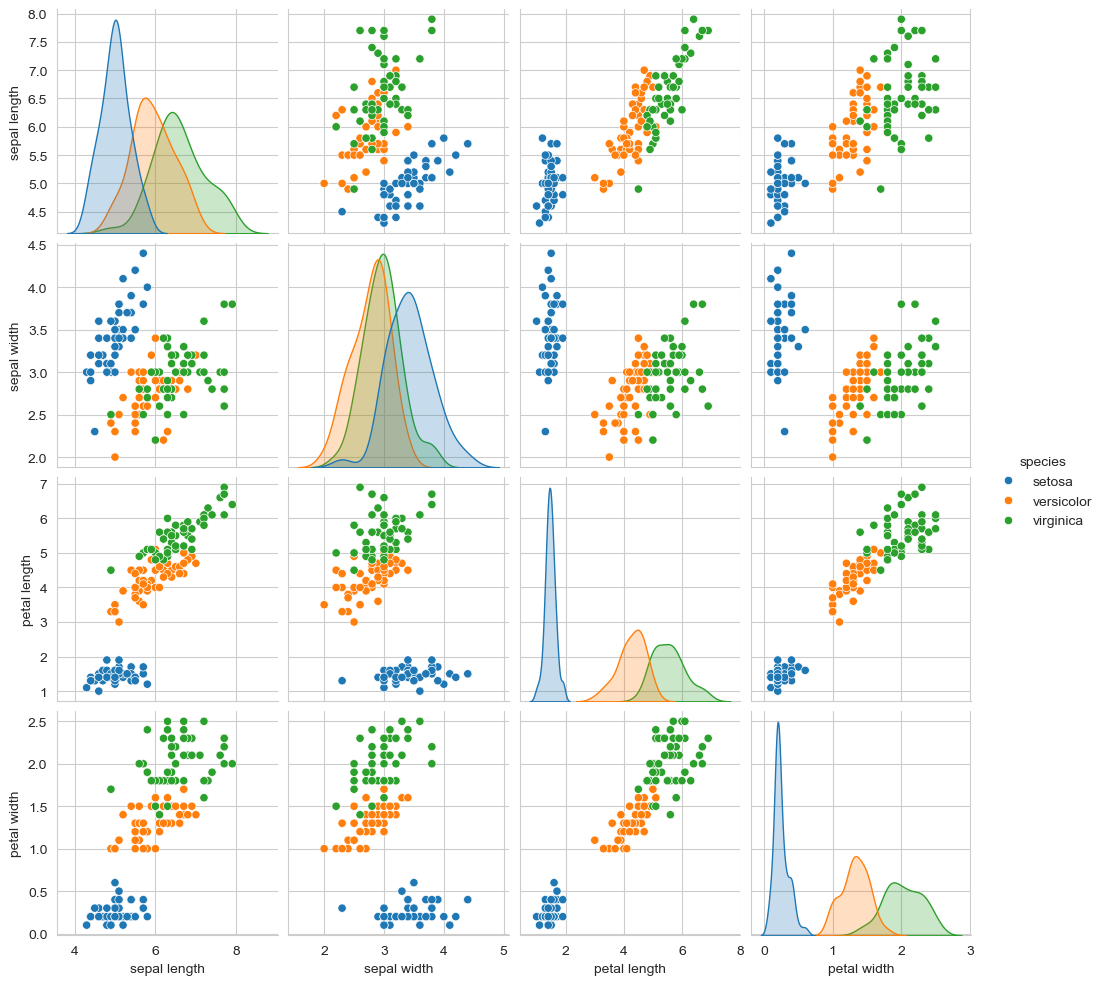

In [4]:
# TODO: Визуализируйте распределение признаков
plt.figure(figsize=(10, 6))
sns.pairplot(df_iris, hue='species')
plt.show()

              sepal length  sepal width  petal length  petal width
sepal length          1.00        -0.12          0.87         0.82
sepal width          -0.12         1.00         -0.43        -0.37
petal length          0.87        -0.43          1.00         0.96
petal width           0.82        -0.37          0.96         1.00
----------


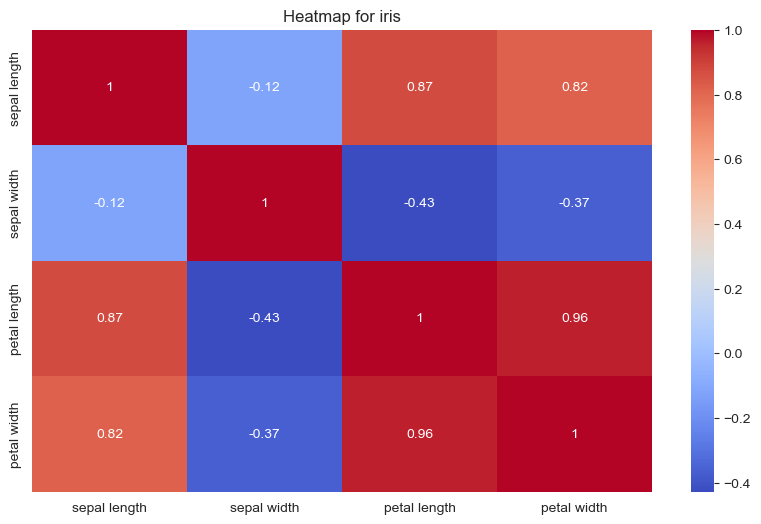

In [5]:
# TODO: Постройте матрицу корреляций
# Подсказка: используйте df_iris.corr() и sns.heatmap()
print(df_iris.iloc[:, :4].corr())
print('-'*10)
plt.figure(figsize=(10, 6))
sns.heatmap(df_iris.iloc[:, :4].corr(), cmap='coolwarm',annot=True)
plt.title('Heatmap for iris')
plt.show()

In [6]:
df_iris.columns

Index(['sepal length', 'sepal width', 'petal length', 'petal width',
       'species'],
      dtype='object')

In [7]:
# 1.3 Подготовка данных

# TODO: Разделите данные на train и test (80/20)
#X = df_iris[['sepal length', 'sepal width', 'petal length', 'petal width']]
#y = df_iris['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TODO: Нормализуйте признаки с помощью StandardScaler
scaler_iris = StandardScaler()
X_train = scaler_iris.fit_transform(X_train)
X_test = scaler_iris.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


Logistic Regression
Accuracy: 0.9333


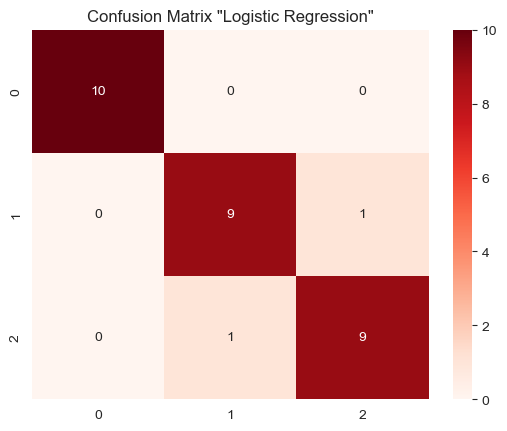

------------------------------
Decision Tree
Accuracy: 0.9333


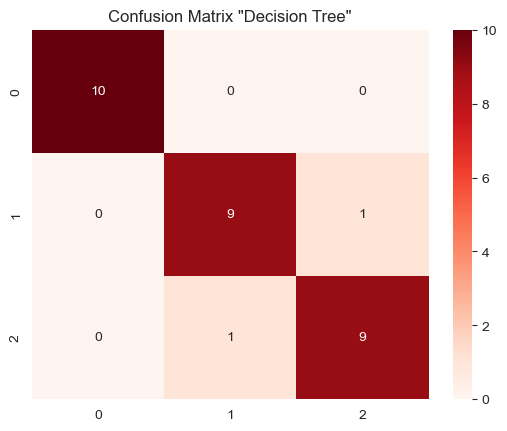

------------------------------
Random Forest
Accuracy: 0.9000


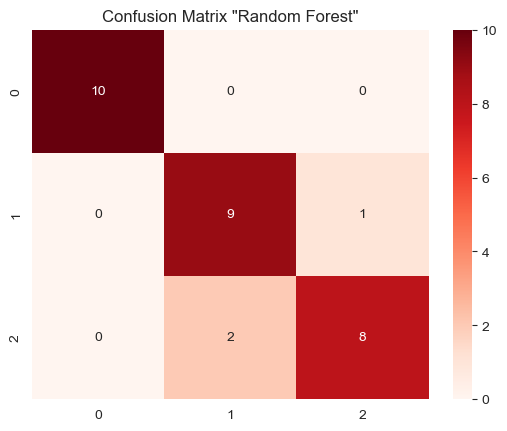

------------------------------
K-Nearest Neighbors
Accuracy: 0.9333


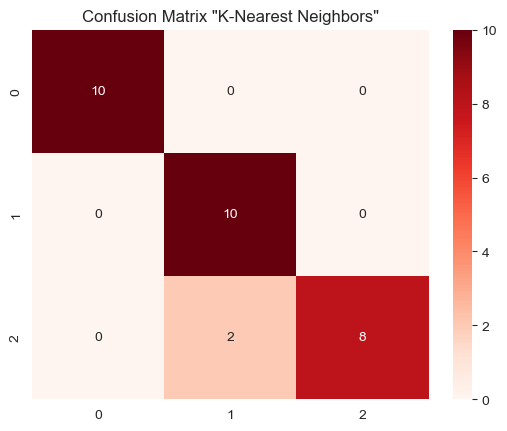

------------------------------
SVM
Accuracy: 1.0000


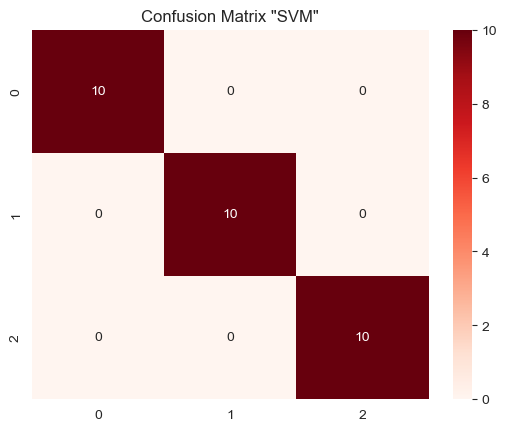

------------------------------


In [8]:
# 1.4 Обучение моделей

# Для каждой модели:
# - Обучите на train данных
# - Сделайте предсказания на test
# - Вычислите accuracy
# - Постройте confusion matrix

# TODO: Обучите следующие модели:
# 1. Logistic Regression
model_logistic = LogisticRegression(random_state=42)
model_logistic.fit(X_train, y_train)

y_pred_logistic = model_logistic.predict(X_test)
acc_logistic = accuracy_score(y_test, y_pred_logistic)
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print('Logistic Regression')
print(f'Accuracy: {acc_logistic:.4f}')
sns.heatmap(cm_logistic, annot=True, cmap='Reds')
plt.title('Confusion Matrix "Logistic Regression"')
plt.show()
print('-'*30)

# 2. Decision Tree
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)

print('Decision Tree')
print(f'Accuracy: {acc_tree:.4f}')
sns.heatmap(cm_tree, annot=True, cmap='Reds')
plt.title('Confusion Matrix "Decision Tree"')
plt.show()
print('-'*30)


# 3. Random Forest
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print('Random Forest')
print(f'Accuracy: {acc_rf:.4f}')
sns.heatmap(cm_rf, annot=True, cmap='Reds')
plt.title('Confusion Matrix "Random Forest"')
plt.show()
print('-'*30)

# 4. K-Nearest Neighbors
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print('K-Nearest Neighbors')
print(f'Accuracy: {acc_knn:.4f}')
sns.heatmap(cm_knn, annot=True, cmap='Reds')
plt.title('Confusion Matrix "K-Nearest Neighbors"')
plt.show()
print('-'*30)

# 5. SVM
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print('SVM')
print(f'Accuracy: {acc_svm:.4f}')
sns.heatmap(cm_svm, annot=True, cmap='Reds')
plt.title('Confusion Matrix "SVM"')
plt.show()
print('-'*30)


In [9]:
# 1.5 Сравнение моделей

logistic_report = classification_report(y_test, y_pred_logistic, output_dict=True)
tree_report = classification_report(y_test, y_pred_tree, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)
svm_report = classification_report(y_test, y_pred_knn, output_dict=True)

result = {
    'model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'K-Nearest Neighbor', 'SVM'],
    'accuracy': [f'{acc_logistic:.3f}', f'{acc_tree:.3f}', f'{acc_rf:.3f}', f'{acc_knn:.3f}', f'{acc_svm:.3f}',],
    'precision_weight': [
        f'{logistic_report['weighted avg']['precision']:.3f}',
        f'{tree_report['weighted avg']['precision']:.3f}',
        f'{rf_report['weighted avg']['precision']:.3f}',
        f'{knn_report['weighted avg']['precision']:.3f}',
        f'{svm_report['weighted avg']['precision']:.3f}',
    ],
    'recall_weight': [
        f'{logistic_report['weighted avg']['recall']:.3f}',
        f'{tree_report['weighted avg']['recall']:.3f}',
        f'{rf_report['weighted avg']['recall']:.3f}',
        f'{knn_report['weighted avg']['recall']:.3f}',
        f'{svm_report['weighted avg']['recall']:.3f}',
    ],
    'f1_score_wight': [
        f'{logistic_report['weighted avg']['f1-score']:.3f}',
        f'{tree_report['weighted avg']['f1-score']:.3f}',
        f'{rf_report['weighted avg']['f1-score']:.3f}',
        f'{knn_report['weighted avg']['f1-score']:.3f}',
        f'{svm_report['weighted avg']['f1-score']:.3f}',
    ]
}
result_df = pd.DataFrame(result)
result_df.sort_values('accuracy', ascending=False)

,model,accuracy,precision_weight,recall_weight,f1_score_wight
4,SVM,1.000,0.944,0.933,0.933
0,Logistic Regression,0.933,0.933,0.933,0.933
1,Decision Tree,0.933,0.933,0.933,0.933
3,K-Nearest Neighbor,0.933,0.944,0.933,0.933
2,Random Forest,0.900,0.902,0.900,0.900


**Вопросы для анализа (ответьте текстом):**

1. Какая модель показала лучшие результаты? Почему, на ваш взгляд?
2. Какие признаки наиболее важны для классификации?
3. Есть ли классы, которые модель путает чаще других? С чем это может быть связано?

**Ваши ответы:**
1. По итоговой таблице наилучшей моделью оказалась SVM, т.к. модель может детектировать нелиные границы между разными классами
2. Наиболее важные признаки - это длина и ширина лепестка: petal_lenght & petal_width. По графику pairplot видно, что они наиболее подходящие параметры для разделения классов
3. Чаще всего модель путается в классах: Versicolor & Virginica, т.к. их признаки достаточно близки друг к другу. На начальном графике pairplor также видно наслоение в жтих классах

---

## Задание 2: Предсказание диабета (3 балла)

### Контекст
Датасет Pima Indians Diabetes содержит медицинские данные женщин индейского племени Пима. Задача — предсказать наличие диабета на основе диагностических измерений.

### Признаки:
- Pregnancies: количество беременностей
- Glucose: концентрация глюкозы в плазме
- BloodPressure: диастолическое давление (мм рт.ст.)
- SkinThickness: толщина кожной складки (мм)
- Insulin: уровень инсулина (mu U/ml)
- BMI: индекс массы тела
- DiabetesPedigreeFunction: функция наследственности диабета
- Age: возраст

### Задача
1. Загрузите и изучите данные
2. Обработайте пропущенные значения
3. Проведите feature engineering
4. Обучите модели с подбором гиперпараметров
5. Проанализируйте важность признаков

In [10]:
# !pip install --upgrade certifi

In [11]:
# 2.1 Загрузка данных
# Датасет можно загрузить так:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df_diabetes = pd.read_csv(url, names=column_names)

print("Размер датасета:", df_diabetes.shape)
print("\nПервые строки:")
df_diabetes.head()

Размер датасета: (768, 9)

Первые строки:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


In [12]:
# 2.2 Исследование данных

# TODO: Проверьте наличие пропущенных значений
# Здесь решил использовать иной метод describe и посомотреть по полю min, где возможны пропуски
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [13]:
# Подсчет кол-ва нулевых значений 
print('Проверка на np.nan')
display((df_diabetes.isna().sum()))
print('='*10)
print('\nПодсчет нулевых значений в столбцах')
display((df_diabetes == 0).sum())

Проверка на np.nan


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Подсчет нулевых значений в столбцах


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

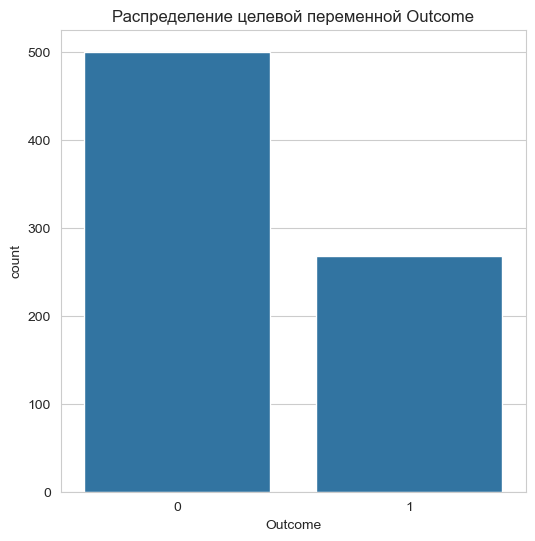

In [14]:
# TODO: Визуализируйте распределение целевой переменной (Outcome)
# Есть ли дисбаланс классов?
df_diabetes['Outcome'].value_counts()

plt.figure(figsize=(6, 6))
sns.countplot(df_diabetes, x='Outcome')
plt.title('Распределение целевой переменной Outcome')
plt.show()

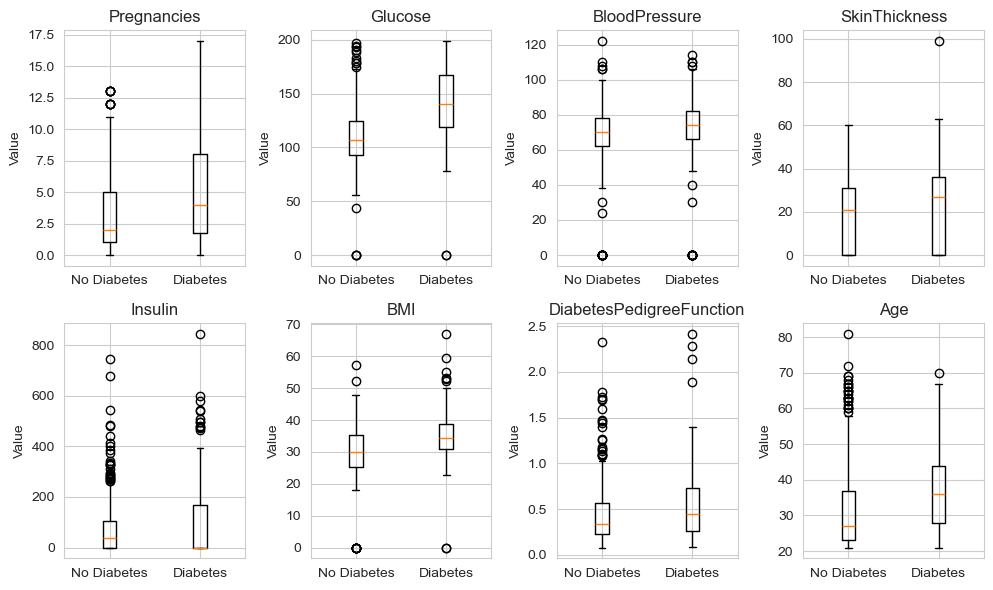

In [15]:
# TODO: Постройте boxplots для числовых признаков по классам
# Какие признаки хорошо разделяют классы?

# Здесь создал список из названия колонок, чтобы разделить по Outcome
feature_columns = [col for col in df_diabetes.columns if col != 'Outcome'] 

fig, axes = plt.subplots(2, 4, figsize=(10, 6))  
axes = axes.ravel()  

for idx, column in enumerate(feature_columns):
    data_to_plot = [df_diabetes[df_diabetes['Outcome'] == 0][column],  
                    df_diabetes[df_diabetes['Outcome'] == 1][column]]  
    
    axes[idx].boxplot(data_to_plot, labels=['No Diabetes', 'Diabetes'])
    axes[idx].set_title(column)
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [16]:
# 2.3 Обработка данных

# TODO: Замените невозможные нули на NaN для следующих признаков:
# Glucose, BloodPressure, SkinThickness, Insulin, BMI

columns_to_replace = ['Glucose', 'BloodPressure', 'Insulin', 'BMI']
df_diabets_clear = df_diabetes.copy()

df_diabets_clear[columns_to_replace] = df_diabets_clear[columns_to_replace].replace(0, np.nan)

# TODO: Заполните пропуски медианными значениями (отдельно для каждого класса)
# Подсказка: используйте df.groupby('Outcome').transform('median')    
df_diabets_clear[columns_to_replace] = (
    df_diabets_clear.groupby('Outcome')[columns_to_replace].transform(lambda x: x.fillna(x.median()))
    )

df_diabets_clear[columns_to_replace].isna().sum()

Glucose          0
BloodPressure    0
Insulin          0
BMI              0
dtype: int64

In [17]:
df_diabets_clear

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.00,72.00,35,169.50,33.60,0.63,50,1
1,1,85.00,66.00,29,102.50,26.60,0.35,31,0
2,8,183.00,64.00,0,169.50,23.30,0.67,32,1
3,1,89.00,66.00,23,94.00,28.10,0.17,21,0
4,0,137.00,40.00,35,168.00,43.10,2.29,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.00,76.00,48,180.00,32.90,0.17,63,0
764,2,122.00,70.00,27,102.50,36.80,0.34,27,0
765,5,121.00,72.00,23,112.00,26.20,0.24,30,0
766,1,126.00,60.00,0,169.50,30.10,0.35,47,1


In [18]:
# 2.4 Feature Engineering

# TODO: Создайте новые признаки, например:
# - Категориальные версии возраста (young, middle, old)
# - Категориальные версии BMI (underweight, normal, overweight, obese)
# - Взаимодействия между признаками (например, Glucose * BMI)
# - Полиномиальные признаки

def age_to_category(age):
    """
    На вход приходит колонка с возрастом -> на выход получаем категоризацию по возрасту 
    18-21 - young
    45-59 - middle 
    75+ - old
    """
    if age < 22: 
        return 'young'
    if age > 74:
        return 'old'
    else:
        return 'middle'

def bmi_category(bmi):
    if pd.isna(bmi):
        return np.nan
    elif bmi < 18.5:
        return 'underweight'
    elif bmi < 25.0:
        return 'normal'
    elif bmi < 30.0:
        return 'overweight'
    else:
        return 'obese'

df_diabets_clear['AgeGroup'] = df_diabets_clear['Age'].apply(age_to_category)
df_diabets_clear['BMIGroup'] = df_diabets_clear['BMI'].apply(bmi_category)
df_diabets_clear['Categorise'] = df_diabets_clear.apply(
    lambda x: x['Glucose'] * x['BMI'], 
    axis=1
)

#df_diabets_clear['Outcome_tech'] = df_diabets_clear['Outcome']

df_diabets_clear

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup,BMIGroup,Categorise
0,6,148.00,72.00,35,169.50,33.60,0.63,50,1,middle,obese,4972.80
1,1,85.00,66.00,29,102.50,26.60,0.35,31,0,middle,overweight,2261.00
2,8,183.00,64.00,0,169.50,23.30,0.67,32,1,middle,normal,4263.90
3,1,89.00,66.00,23,94.00,28.10,0.17,21,0,young,overweight,2500.90
4,0,137.00,40.00,35,168.00,43.10,2.29,33,1,middle,obese,5904.70
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101.00,76.00,48,180.00,32.90,0.17,63,0,middle,obese,3322.90
764,2,122.00,70.00,27,102.50,36.80,0.34,27,0,middle,obese,4489.60
765,5,121.00,72.00,23,112.00,26.20,0.24,30,0,middle,overweight,3170.20
766,1,126.00,60.00,0,169.50,30.10,0.35,47,1,middle,obese,3792.60


In [19]:
# 2.5 Подготовка данных
df_diabetes_model = pd.get_dummies(df_diabets_clear)

X = df_diabetes_model.drop(columns=('Outcome'))
y = df_diabetes['Outcome']
# TODO: Разделите данные на X и y


# TODO: Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
base_lr = LogisticRegression()

In [21]:
# TODO: Нормализация признаков
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Categorise']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [22]:
# 2.6 Baseline модель

# TODO: Обучите простую Logistic Regression без подбора параметров
# Это будет ваш baseline для сравнения
model_logistic = LogisticRegression()
model_logistic.fit(X_train, y_train)

y_pred_logistic = model_logistic.predict(X_test)
acc_logistic = accuracy_score(y_test, y_pred_logistic)
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print(f"Accuracy: {acc_logistic}")
print(f"Confusion matrix:\n {cm_logistic}")

Accuracy: 0.7727272727272727
Confusion matrix:
 [[83 16]
 [19 36]]


In [23]:
# 2.7 Подбор гиперпараметров

# TODO: Используйте GridSearchCV для подбора гиперпараметров Random Forest
# Параметры для поиска:
# - n_estimators: [50, 100, 200]
# - max_depth: [5, 10, 15, None]
# - min_samples_split: [2, 5, 10]
# - min_samples_leaf: [1, 2, 4]

# Используйте cv=5 и scoring='roc_auc'

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    
    scoring='roc_auc',       
    n_jobs=-1,               
    verbose=1                
)

grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC-AUC на тестовой выборке: {test_roc_auc:.4f}")
print(f"Accuracy на тестовой выборке: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучший ROC-AUC на кросс-валидации: 0.9413
ROC-AUC на тестовой выборке: 0.9231
Accuracy на тестовой выборке: 0.8701

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        99
           1       0.80      0.85      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154



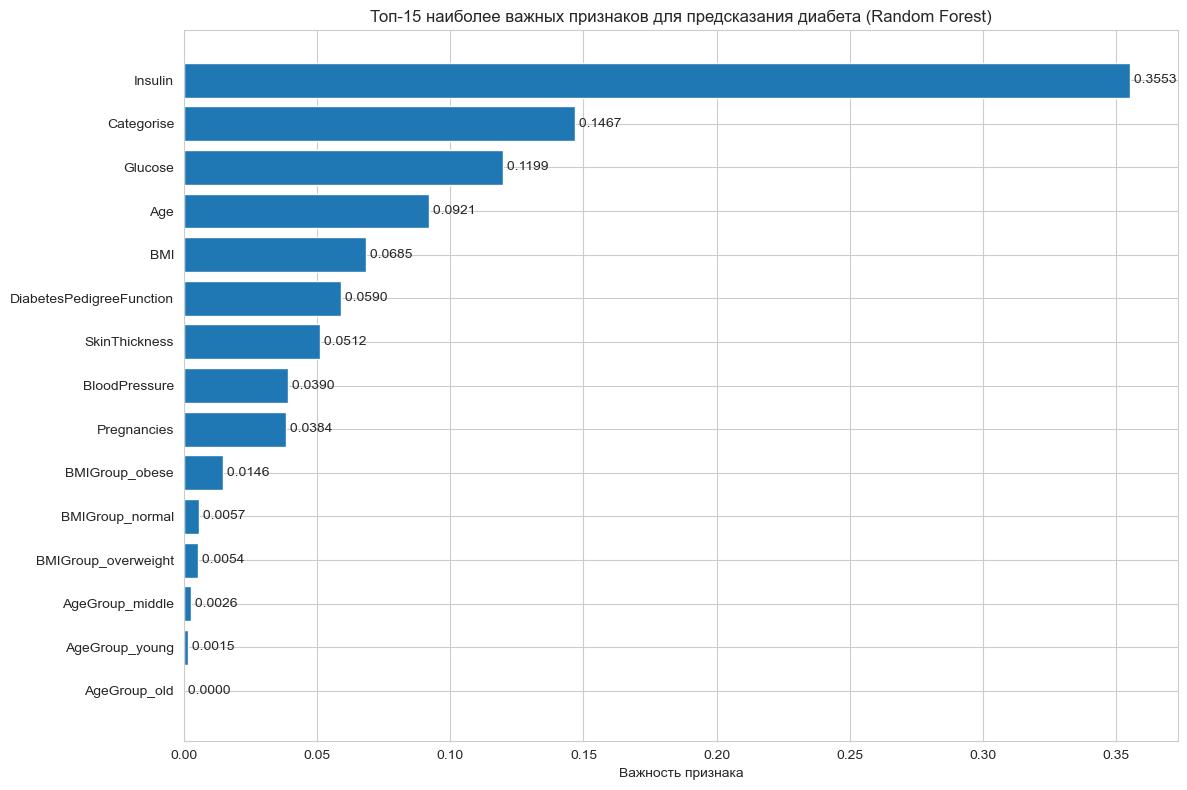

In [24]:
# 2.8 Анализ важности признаков

# TODO: Постройте график важности признаков для лучшей модели Random Forest
# Какие признаки наиболее важны для предсказания диабета?

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
})

feature_importance = feature_importance[
    ~feature_importance['feature'].str.contains('Outcome', case=False, na=False)
].sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
bars = plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)

for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values)):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=10)

plt.xlabel('Важность признака')
plt.title('Топ-15 наиболее важных признаков для предсказания диабета (Random Forest)')
plt.gca().invert_yaxis()  # Инвертируем, чтобы самый важный был сверху
plt.tight_layout()
plt.show()

ДЕТАЛЬНЫЙ АНАЛИЗ МЕТРИК ДЛЯ КАЖДОГО КЛАССА

    КЛАСС 0 (Нет диабета)      |        КЛАСС 1 (Диабет)       
--------------------------------------------------------------
Precision: 0.9158 (91.58%)          | Precision: 0.7966 (79.66%)
Recall:    0.8788 (87.88%)          | Recall:    0.8545 (85.45%)
F1-score:  0.8969 (89.69%)          | F1-score:  0.8246 (82.46%)
--------------------------------------------------------------
  Общая точность (Accuracy):   0.8701 (87.01%)

ПОДРОБНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

 Нет диабета       0.92      0.88      0.90        99
      Диабет       0.80      0.85      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.87      0.86       154
weighted avg       0.87      0.87      0.87       154



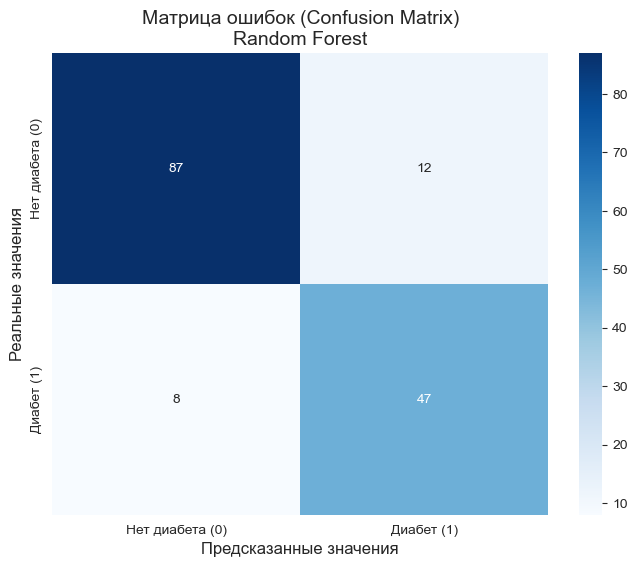

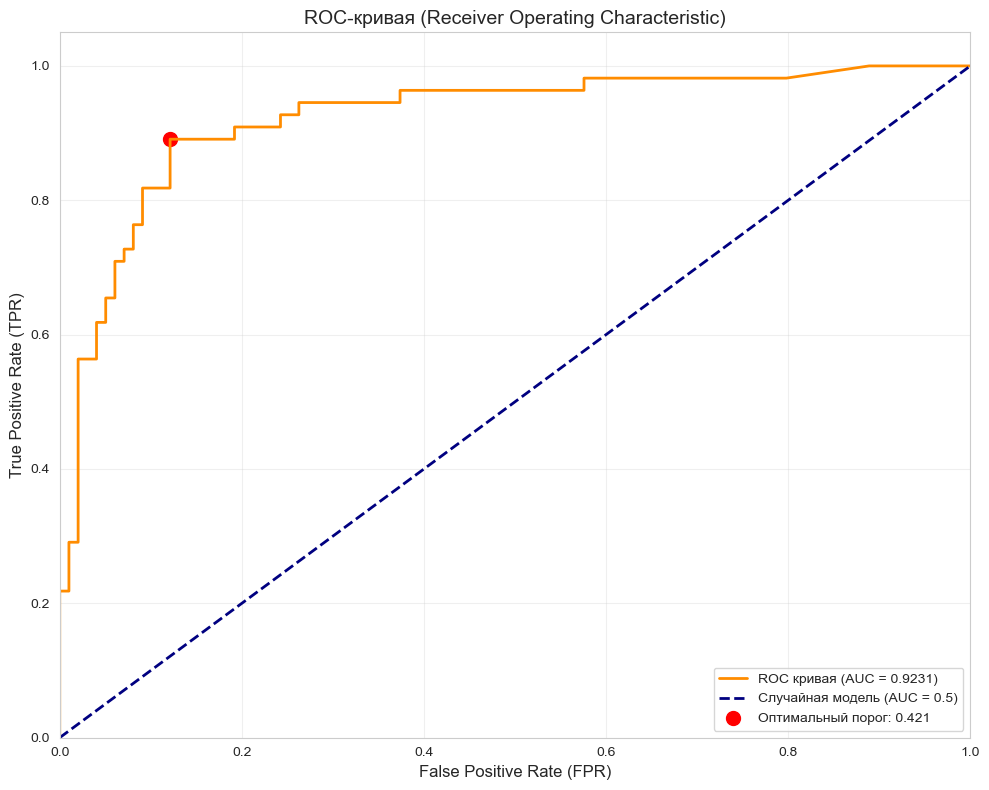

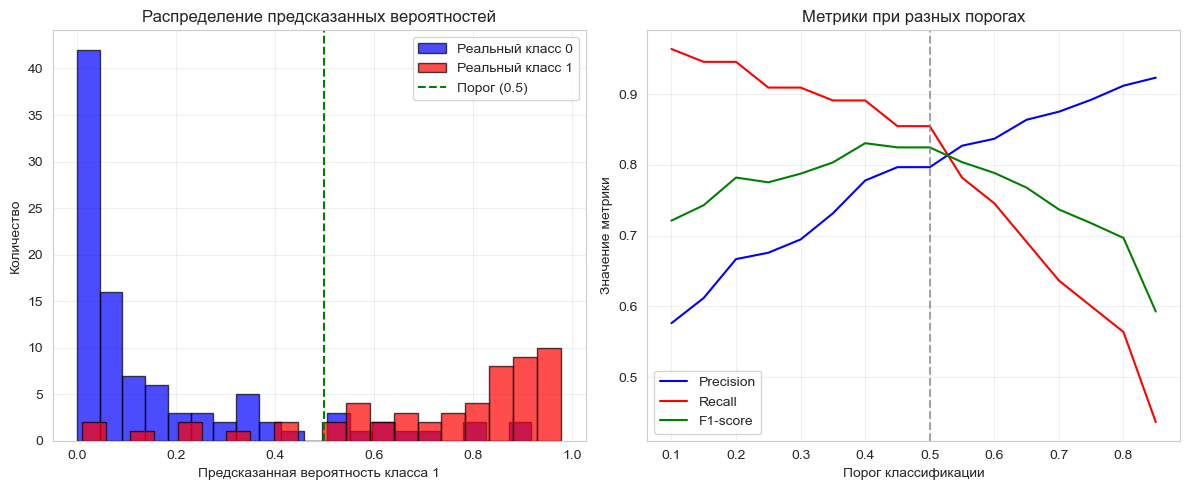

In [25]:
# 2.9 Анализ ошибок

# TODO: Постройте confusion matrix
# TODO: Вычислите precision, recall, F1 для обоих классов
# TODO: Постройте ROC-кривую и вычислите AUC
# 2.9 Анализ ошибок 

y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Нет диабета (0)', 'Диабет (1)'],
            yticklabels=['Нет диабета (0)', 'Диабет (1)'])
plt.title(f'Матрица ошибок (Confusion Matrix)\nRandom Forest', fontsize=14)
plt.ylabel('Реальные значения', fontsize=12)
plt.xlabel('Предсказанные значения', fontsize=12)

print("=" * 60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ МЕТРИК ДЛЯ КАЖДОГО КЛАССА")
print("=" * 60)

precision_0 = precision_score(y_test, y_pred, pos_label=0)
recall_0 = recall_score(y_test, y_pred, pos_label=0)
f1_0 = f1_score(y_test, y_pred, pos_label=0)

precision_1 = precision_score(y_test, y_pred, pos_label=1)
recall_1 = recall_score(y_test, y_pred, pos_label=1)
f1_1 = f1_score(y_test, y_pred, pos_label=1)

accuracy = (cm[0,0] + cm[1,1]) / cm.sum()

print(f"\n{'КЛАСС 0 (Нет диабета)':^30} | {'КЛАСС 1 (Диабет)':^30}")
print("-" * 62)
print(f"Precision: {precision_0:.4f} ({precision_0*100:.2f}%)          | Precision: {precision_1:.4f} ({precision_1*100:.2f}%)")
print(f"Recall:    {recall_0:.4f} ({recall_0*100:.2f}%)          | Recall:    {recall_1:.4f} ({recall_1*100:.2f}%)")
print(f"F1-score:  {f1_0:.4f} ({f1_0*100:.2f}%)          | F1-score:  {f1_1:.4f} ({f1_1*100:.2f}%)")
print("-" * 62)
print(f"{'Общая точность (Accuracy):':^30} {accuracy:.4f} ({accuracy*100:.2f}%)")

# Используем classification_report для подробного отчета
print("\n" + "=" * 60)
print("ПОДРОБНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Нет диабета', 'Диабет']))

# TODO: Постройте ROC-кривую и вычислите AUC
# Вычисляем ROC кривую
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Визуализация ROC кривой
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Случайная модель (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривая (Receiver Operating Characteristic)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Добавляем аннотации с лучшим порогом
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', s=100,
            label=f'Оптимальный порог: {optimal_threshold:.3f}')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Дополнительный анализ: распределение вероятностей
plt.figure(figsize=(12, 5))

# Гистограмма предсказанных вероятностей
plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7, color='blue', 
         label='Реальный класс 0', edgecolor='black')
plt.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7, color='red', 
         label='Реальный класс 1', edgecolor='black')
plt.axvline(x=0.5, color='green', linestyle='--', label='Порог (0.5)')
plt.xlabel('Предсказанная вероятность класса 1')
plt.ylabel('Количество')
plt.title('Распределение предсказанных вероятностей')
plt.legend()
plt.grid(True, alpha=0.3)

# Анализ ошибок по порогам
plt.subplot(1, 2, 2)
thresholds_range = np.arange(0.1, 0.9, 0.05)
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds_range:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))

plt.plot(thresholds_range, precisions, 'b-', label='Precision')
plt.plot(thresholds_range, recalls, 'r-', label='Recall')
plt.plot(thresholds_range, f1_scores, 'g-', label='F1-score')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.title('Метрики при разных порогах')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопросы для анализа:**

1. Какие признаки оказались наиболее важными? Соответствует ли это медицинским знаниям?
2. Какой тип ошибок (False Positive или False Negative) более критичен в этой задаче?
3. Как можно улучшить модель?
4. Как обработка пропущенных значений повлияла на результаты?

**Ваши ответы:**
1. Наиболее важные признаки: ```Glucose```, ```Age```, ```BMI```, ```DiabetesPedigreeFunction```, что согласуется с медицинскими факторами риска диабета
2. False Negative - более критичая ошибка, т.к. в таком случае модель будет пропускать больного человека -> он не будет получать лечения
3. Можно через балансировку классов или калибровку порога классификации под клиническую цель 
4. Заполнение стабилизирует модель: уменьшается шум в данных и улучшается качество ROC-AUC

---

## Задание 3: Регрессия — предсказание экспрессии генов (3 балла)

### Контекст
В этом задании мы будем работать с синтетическими данными об экспрессии генов. Задача — предсказать уровень экспрессии целевого гена на основе уровней экспрессии других генов и условий эксперимента.

### Задача
1. Сгенерируйте синтетические данные
2. Проведите анализ данных
3. Обучите регрессионные модели
4. Сравните их производительность
5. Проанализируйте residuals (остатки)

In [26]:
# 3.1 Генерация синтетических данных

np.random.seed(42)

n_samples = 500
n_genes = 50

# Экспрессия генов (логнормальное распределение)
gene_expression = np.random.lognormal(mean=2, sigma=1, size=(n_samples, n_genes))

# Условия эксперимента
temperature = np.random.uniform(20, 37, n_samples)
ph = np.random.uniform(6.5, 7.5, n_samples)
treatment = np.random.choice(['control', 'drug_A', 'drug_B'], n_samples)

# Целевой ген зависит от нескольких других генов и условий
target_gene = (
    2.5 * gene_expression[:, 0] + 
    1.8 * gene_expression[:, 5] - 
    0.5 * gene_expression[:, 10] +
    0.3 * temperature +
    5.0 * ph +
    np.where(treatment == 'drug_A', 10, 0) +
    np.where(treatment == 'drug_B', -5, 0) +
    np.random.normal(0, 5, n_samples)  # шум
)

# Создаём DataFrame
df_genes = pd.DataFrame(gene_expression, columns=[f'gene_{i}' for i in range(n_genes)])
df_genes['temperature'] = temperature
df_genes['ph'] = ph
df_genes['treatment'] = treatment
df_genes['target_gene'] = target_gene

print("Размер датасета:", df_genes.shape)
df_genes.head()

Размер датасета: (500, 54)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,gene_10,gene_11,gene_12,gene_13,gene_14,gene_15,gene_16,gene_17,gene_18,gene_19,gene_20,gene_21,gene_22,gene_23,gene_24,gene_25,gene_26,gene_27,gene_28,gene_29,gene_30,gene_31,gene_32,gene_33,gene_34,gene_35,gene_36,gene_37,gene_38,gene_39,gene_40,gene_41,gene_42,gene_43,gene_44,gene_45,gene_46,gene_47,gene_48,gene_49,temperature,ph,treatment,target_gene
0,12.14,6.43,14.12,33.89,5.85,5.85,35.85,15.92,4.62,12.71,4.65,4.64,9.41,1.09,1.32,4.21,2.68,10.12,2.98,1.80,32.00,5.90,7.91,1.78,4.29,8.26,2.34,10.76,4.05,5.52,4.05,47.10,7.29,2.57,16.82,2.18,9.11,1.04,1.96,9.00,15.46,8.77,6.58,5.47,1.68,3.60,4.66,21.27,10.42,1.27,29.10,6.84,drug_B,76.70
1,10.22,5.03,3.75,13.62,20.72,18.75,3.19,5.42,10.29,19.60,4.58,6.14,2.44,2.23,16.65,28.68,6.88,20.16,10.61,3.88,10.61,34.40,7.13,35.33,0.54,16.81,8.06,5.48,8.10,1.01,5.93,10.56,32.39,4.40,3.29,4.47,18.46,10.27,4.35,12.35,8.14,19.47,3.66,5.32,4.99,1.71,9.94,9.59,7.43,5.84,36.92,7.32,control,97.35
2,1.79,4.85,5.25,3.31,6.29,11.07,48.72,8.80,9.56,6.86,1.08,7.20,7.85,86.77,6.10,9.99,7.14,2.30,23.17,15.67,16.30,2.98,30.05,1.82,13.29,66.05,2.74,4.19,8.16,4.47,1.57,7.91,2.55,11.86,2.95,34.81,3.38,5.35,16.67,2.16,9.28,27.31,1.48,8.89,9.58,16.15,2.14,1.97,12.45,9.94,22.42,6.56,drug_B,60.52
3,9.49,10.45,3.74,9.32,9.91,3.62,47.74,11.87,2.24,14.25,2.79,16.23,23.54,3.25,19.36,11.16,16.81,49.24,5.78,3.48,3.04,3.27,6.84,10.39,9.74,16.90,7.49,31.61,5.67,112.19,13.81,3.14,2.53,11.97,5.91,15.09,11.86,6.87,3.17,1.62,4.73,17.40,9.15,2.13,8.79,10.86,3.05,8.62,7.83,2.36,34.66,6.83,drug_A,82.44
4,10.57,12.95,21.82,21.20,1.86,2.89,12.37,12.35,12.37,348.18,13.08,23.00,19.18,14.17,5.39,15.78,3.41,5.83,4.55,8.02,74.79,1.14,14.68,1.47,4.61,21.95,7.88,2.51,3.61,14.58,3.56,9.17,7.73,3.85,63.05,13.93,0.98,8.90,3.81,17.33,3.35,6.59,12.24,17.56,2.22,5.29,4.60,3.84,43.18,11.08,28.45,6.59,drug_B,59.46


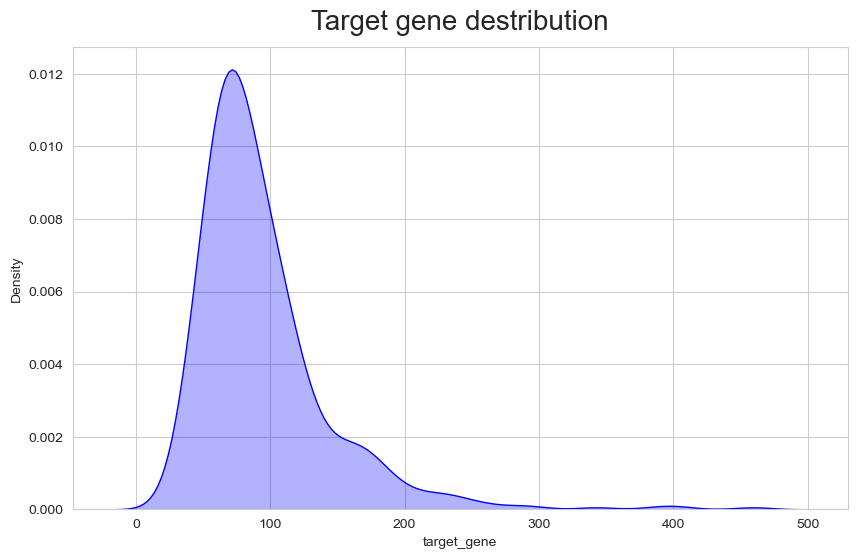

In [27]:
# 3.2 Разведочный анализ

# TODO: Постройте распределение целевой переменной
plt.figure(figsize=(10, 6))
sns.kdeplot(df_genes['target_gene'], fill=True, color='blue', alpha=0.3)
plt.title('Target gene destribution', y=1.02, size=20)
plt.show()

In [28]:
# TODO: Найдите топ-10 генов с наибольшей корреляцией с target_gene
# Подсказка: используйте df_genes.corr()['target_gene'].sort_values()
df_genes[[c for c in df_genes.columns if c not in ['temperature', 'ph', 'treatment']]].corr()['target_gene'].sort_values(ascending=False).head(11)

target_gene   1.00
gene_0        0.74
gene_5        0.64
gene_4        0.05
gene_1        0.04
gene_6        0.04
gene_17       0.03
gene_30       0.03
gene_19       0.03
gene_22       0.02
gene_49       0.02
Name: target_gene, dtype: float64

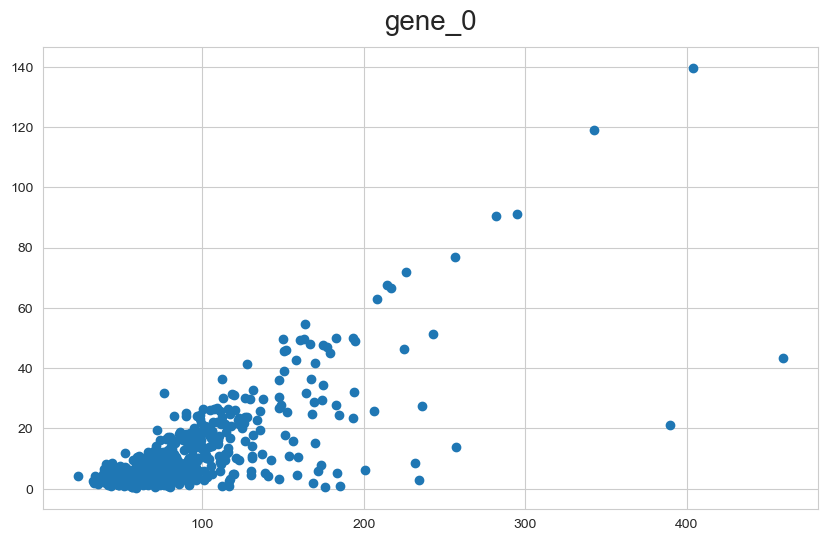

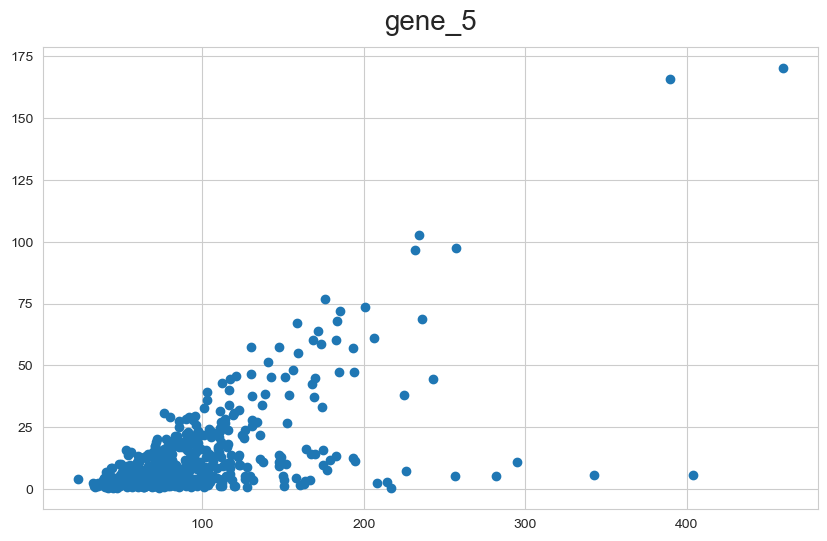

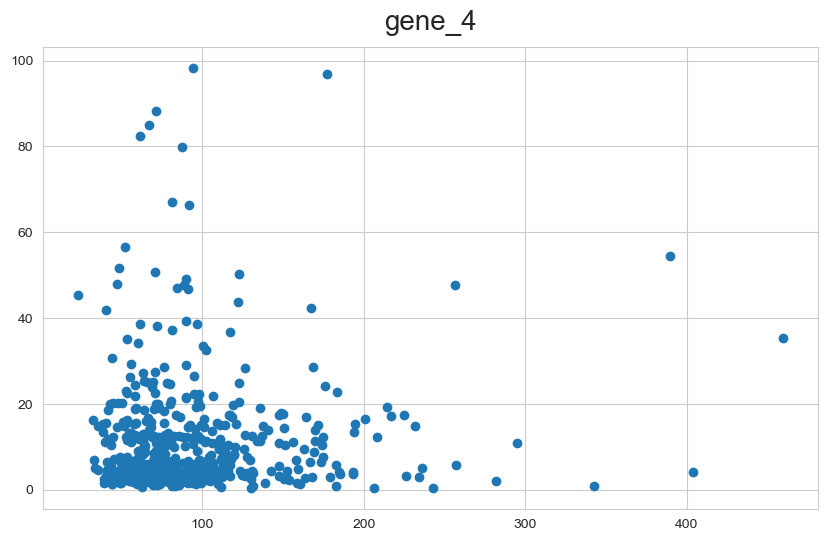

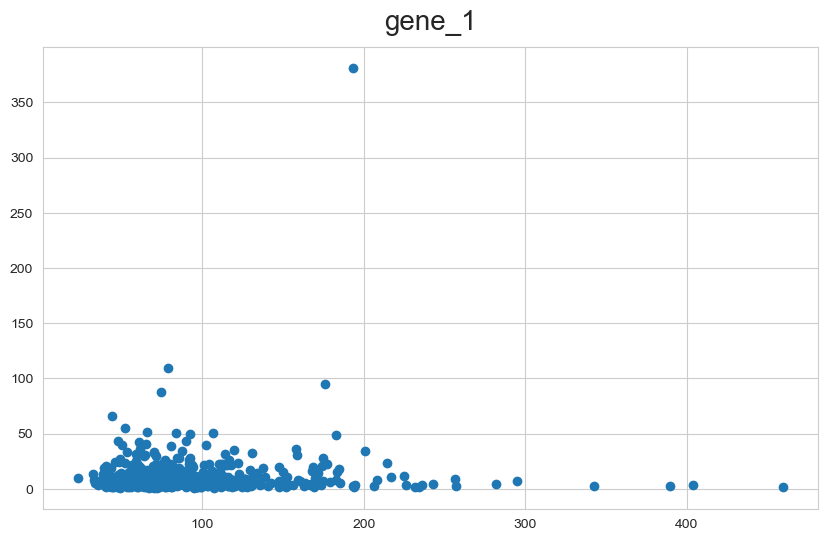

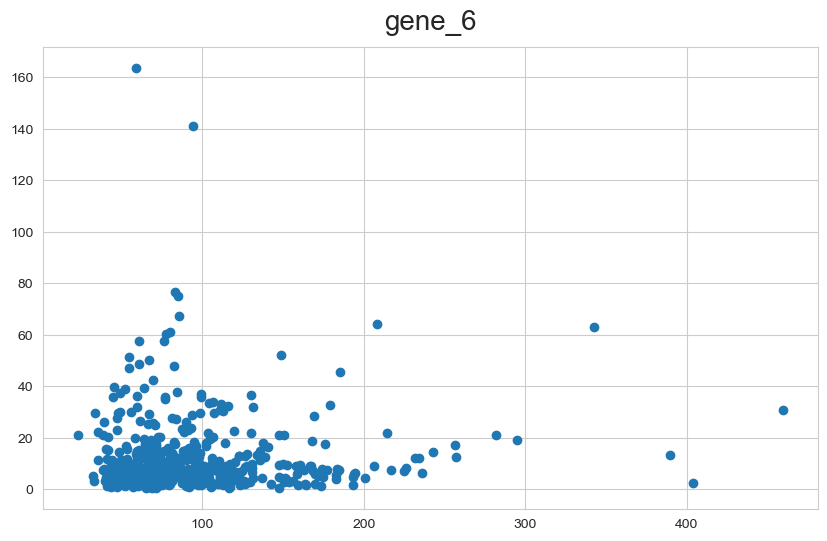

In [29]:
# TODO: Постройте scatter plots для топ-5 генов vs target_gene

plt.figure(figsize=(10, 6))
plt.scatter(data=df_genes, x='target_gene', y='gene_0')
plt.title('gene_0', y=1.02, size=20)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data=df_genes, x='target_gene', y='gene_5')
plt.title('gene_5', y=1.02, size=20)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data=df_genes, x='target_gene', y='gene_4')
plt.title('gene_4', y=1.02, size=20)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data=df_genes, x='target_gene', y='gene_1')
plt.title('gene_1', y=1.02, size=20)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(data=df_genes, x='target_gene', y='gene_6')
plt.title('gene_6', y=1.02, size=20)
plt.show()

<Figure size 1000x600 with 0 Axes>

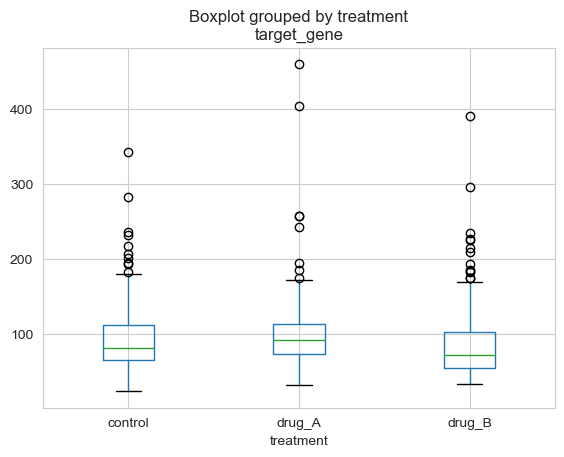

In [30]:
# TODO: Визуализируйте влияние treatment на target_gene (boxplot)
plt.figure(figsize=(10, 6))
df_genes.boxplot(column='target_gene', by='treatment')
plt.show()

In [31]:
# TODO: Преобразуйте категориальную переменную treatment в dummy variables
# Подсказка: pd.get_dummies()
treatment_dummies = pd.get_dummies(df_genes['treatment'], prefix='treatment', drop_first=True)
df_genes_new = pd.concat([df_genes.drop('treatment', axis=1), treatment_dummies], axis=1)

# TODO: Разделите на X и y

X = df_genes_new.drop('target_gene', axis=1)
y = df_genes_new['target_gene']
# TODO: Train/test split (80/20)

In [32]:
# 3.3 Подготовка данных

# TODO: Преобразуйте категориальную переменную treatment в dummy variables
# Подсказка: pd.get_dummies()
treatment_dummies = pd.get_dummies(df_genes['treatment'], prefix='treatment')
df_genes_new = pd.concat([df_genes.drop('treatment', axis=1), treatment_dummies], axis=1)

# TODO: Разделите на X и y

X = df_genes_new.drop('target_gene', axis=1)
y = df_genes_new['target_gene']
# TODO: Train/test split (80/20)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Нормализация признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
# 3.4 Обучение моделей
results_for_models = []

# TODO: Обучите следующие регрессионные модели:
# 1. Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

results_for_models.append({
    'Model': 'Linear Regression',
    'MSE': mse_lr,
    'RMSE': rmse_lr, 
    'MAE': mae_lr,
    'R2': r2_lr
})

# 2. Ridge Regression (с подбором alpha через GridSearchCV)

model_ridge = Ridge()

ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(
    model_ridge, 
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
best_ridge.fit(X_train, y_train)
y_pred_brg = best_ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_brg)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_brg)
r2_ridge = r2_score(y_test, y_pred_brg)

results_for_models.append({
    'Model': 'Linear Regression',
    'MSE': mse_ridge,
    'RMSE': rmse_ridge, 
    'MAE': mae_ridge,
    'R2': r2_ridge
})

print(results_for_models)
# 3. Lasso Regression (с подбором alpha через GridSearchCV)
# 4. Decision Tree Regressor
# 5. Random Forest Regressor
# 6. SVR (Support Vector Regression)

# Для каждой модели вычислите:
# - MSE, RMSE, MAE, R²


[{'Model': 'Linear Regression', 'MSE': 40.04055970917113, 'RMSE': np.float64(6.3277610344553255), 'MAE': 5.447218091975315, 'R2': 0.9833064003188446}, {'Model': 'Linear Regression', 'MSE': 39.82661542035474, 'RMSE': np.float64(6.310833179569457), 'MAE': 5.422416804729827, 'R2': 0.9833955973814609}]


In [34]:
# 3.4 Обучение моделей

# TODO: Обучите следующие регрессионные модели:
# 1. Linear Regression
# 2. Ridge Regression (с подбором alpha через GridSearchCV)
# 3. Lasso Regression (с подбором alpha через GridSearchCV)
# 4. Decision Tree Regressor
# 5. Random Forest Regressor
# 6. SVR (Support Vector Regression)

# Для каждой модели вычислите:
# - MSE, RMSE, MAE, R²


results = []

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

results.append({
    'Model': 'Linear Regression',
    'MSE': mse_lr,
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'R2': r2_lr
})

ridge = Ridge()

ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(
    ridge, 
    ridge_params, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

results.append({
    'Model': f'Ridge (alpha={ridge_grid.best_params_["alpha"]})',
    'MSE': mse_ridge,
    'RMSE': rmse_ridge,
    'MAE': mae_ridge,
    'R2': r2_ridge
})

lasso = Lasso(max_iter=10000)

lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

lasso_grid = GridSearchCV(
    lasso, 
    lasso_params, 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

results.append({
    'Model': f'Lasso (alpha={lasso_grid.best_params_["alpha"]})',
    'MSE': mse_lasso,
    'RMSE': rmse_lasso,
    'MAE': mae_lasso,
    'R2': r2_lasso
})

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

results.append({
    'Model': 'Decision Tree',
    'MSE': mse_dt,
    'RMSE': rmse_dt,
    'MAE': mae_dt,
    'R2': r2_dt
})


rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

results.append({
    'Model': 'Random Forest',
    'MSE': mse_rf,
    'RMSE': rmse_rf,
    'MAE': mae_rf,
    'R2': r2_rf
})

svr = SVR(kernel='rbf', C=100, gamma='scale')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)

mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

results.append({
    'Model': 'SVR (RBF kernel)',
    'MSE': mse_svr,
    'RMSE': rmse_svr,
    'MAE': mae_svr,
    'R2': r2_svr
})

# 3.5 Сравнение моделей

# TODO: Создайте таблицу с метриками всех моделей
results_df = pd.DataFrame(results)
results_df = results_df.round(4)  

print('Результирующая таблица')
print(results_df.to_string(index=False))

Результирующая таблица
            Model    MSE  RMSE   MAE   R2
Linear Regression  40.04  6.33  5.45 0.98
Ridge (alpha=1.0)  39.83  6.31  5.42 0.98
Lasso (alpha=0.1)  36.21  6.02  5.20 0.98
    Decision Tree 792.12 28.14 15.52 0.67
    Random Forest 746.75 27.33 13.38 0.69
 SVR (RBF kernel) 763.25 27.63 15.74 0.68


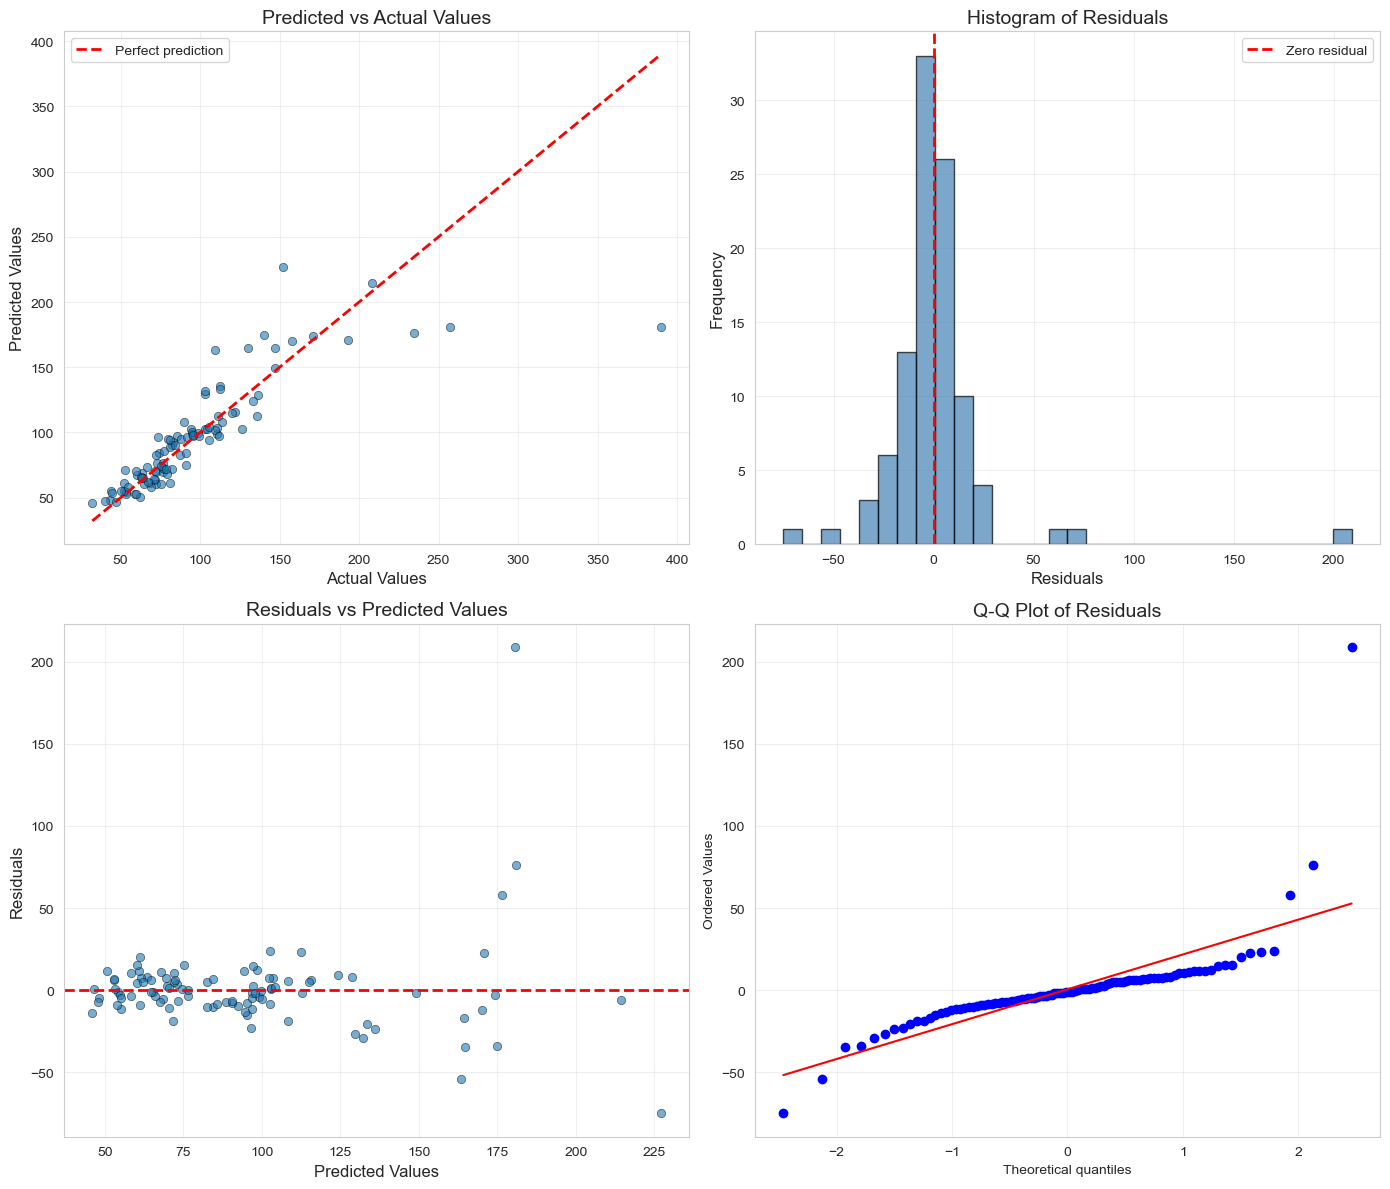

Аналих остатков - статистический тест

Тест Шапиро-Уилка:
  t-stat: 0.6057
  p-value: 0.0000

Анализ остатков. Саммари:
  Mean: 0.5005
  Std: 27.4598
  Min: -75.1075
  Max: 208.9592


In [35]:
# 3.6 Анализ residuals (остатков)
import scipy.stats as stats
from scipy.stats import probplot

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

residuals = y_test - y_pred_rf

# 1. График predicted vs actual
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual Values', fontsize=12)
axes[0, 0].set_ylabel('Predicted Values', fontsize=12)
axes[0, 0].set_title('Predicted vs Actual Values', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero residual')
axes[0, 1].set_xlabel('Residuals', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Histogram of Residuals', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals vs Predicted (проверка гомоскедастичности)
axes[1, 0].scatter(y_pred_rf, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Values', fontsize=12)
axes[1, 0].set_ylabel('Residuals', fontsize=12)
axes[1, 0].set_title('Residuals vs Predicted Values', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# 4. QQ-plot residuals (проверка нормальности)
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("Аналих остатков - статистический тест")
print("=" * 60)

shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000] if len(residuals) > 5000 else residuals)
print(f"\nТест Шапиро-Уилка:")
print(f"  t-stat: {shapiro_stat:.4f}")
print(f"  p-value: {shapiro_p:.4f}")

print(f"\nАнализ остатков. Саммари:")
print(f"  Mean: {residuals.mean():.4f}")
print(f"  Std: {residuals.std():.4f}")
print(f"  Min: {residuals.min():.4f}")
print(f"  Max: {residuals.max():.4f}")

LASSO РЕГРЕССИЯ - АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

Количество признаков с ненулевыми коэффициентами: 53
Количество признаков с нулевыми коэффициентами: 2

Топ-10 наиболее важных признаков (по абсолютному значению коэффициента):
         Feature  Coefficient  Abs_Coefficient
          gene_0        40.28            40.28
          gene_5        29.16            29.16
         gene_10        -6.34             6.34
treatment_drug_A         4.33             4.33
treatment_drug_B        -2.61             2.61
     temperature         1.49             1.49
              ph         1.37             1.37
         gene_36         0.55             0.55
         gene_49         0.47             0.47
          gene_4        -0.46             0.46

СЛУЧАЙНЫЙ ЛЕС - АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

Топ-10 наиболее важных признаков (Случайный лес):
         Feature  Importance
          gene_0        0.60
          gene_5        0.23
         gene_11        0.03
         gene_13        0.02
         gene_10      

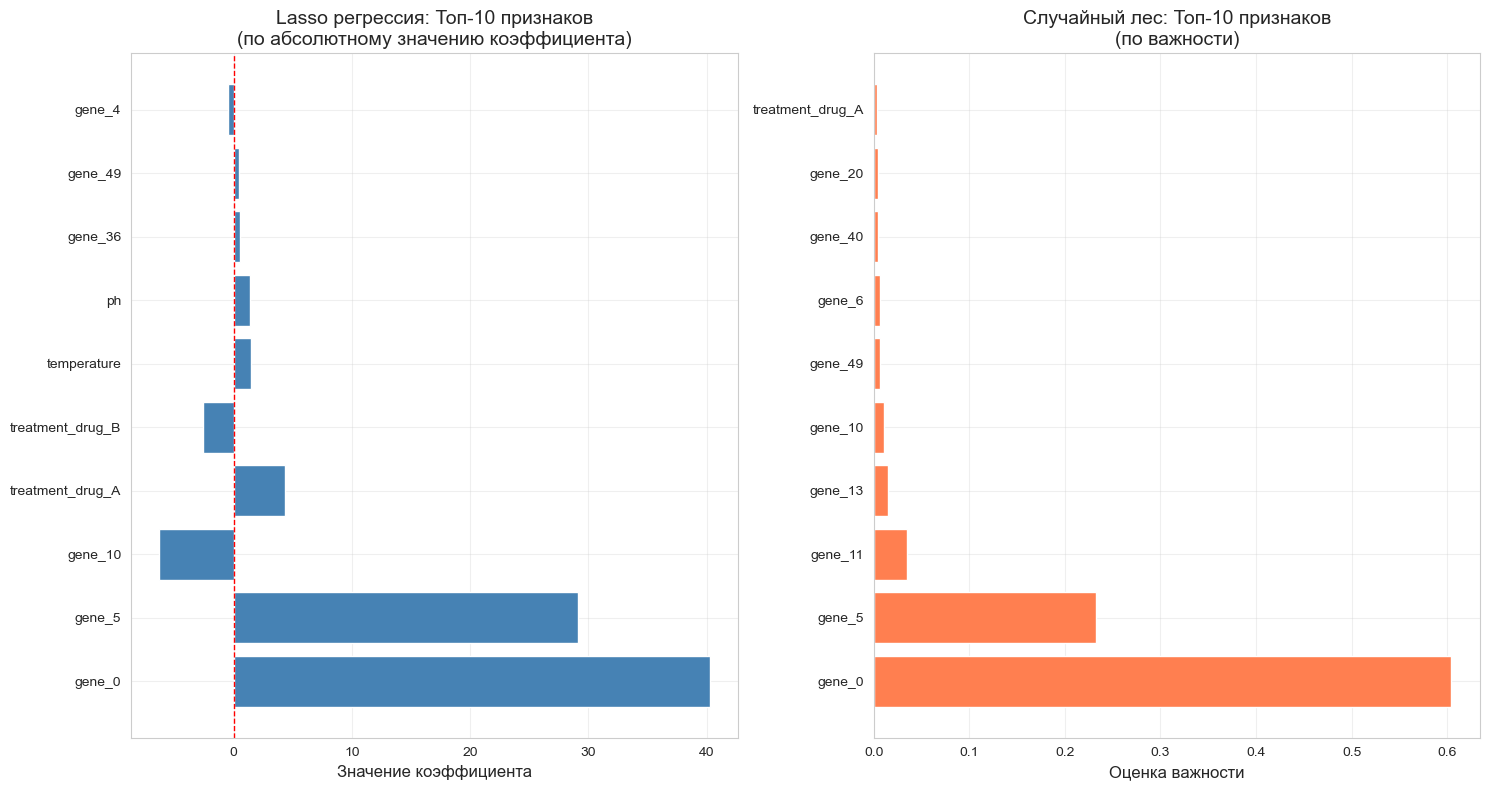

In [36]:
# 3.7 Анализ важности признаков
feature_names = X.columns.tolist()

# TODO: Для Lasso модели — найдите признаки с ненулевыми коэффициентами
print("=" * 60)
print("LASSO РЕГРЕССИЯ - АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("=" * 60)

lasso_model = Lasso(alpha=0.01, max_iter=10000, random_state=42)
lasso_model.fit(X_train, y_train)

lasso_coefficients = lasso_model.coef_
lasso_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefficients,
    'Abs_Coefficient': np.abs(lasso_coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

non_zero_lasso = lasso_feature_importance[lasso_feature_importance['Coefficient'] != 0]
print(f"\nКоличество признаков с ненулевыми коэффициентами: {len(non_zero_lasso)}")
print(f"Количество признаков с нулевыми коэффициентами: {len(lasso_feature_importance) - len(non_zero_lasso)}")
print("\nТоп-10 наиболее важных признаков (по абсолютному значению коэффициента):")
print(non_zero_lasso.head(10).to_string(index=False))

# TODO: Для Random Forest — постройте график важности признаков
print("\n" + "=" * 60)
print("СЛУЧАЙНЫЙ ЛЕС - АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("=" * 60)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nТоп-10 наиболее важных признаков (Случайный лес):")
print(rf_feature_importance.head(10).to_string(index=False))

# TODO: Сравните результаты обоих методов
print("\n" + "=" * 60)
print("СРАВНЕНИЕ: LASSO vs СЛУЧАЙНЫЙ ЛЕС")
print("=" * 60)

top5_lasso = non_zero_lasso.head(5)['Feature'].tolist()
top5_rf = rf_feature_importance.head(5)['Feature'].tolist()

print("\nТоп-5 признаков по версии Lasso:")
for i, feature in enumerate(top5_lasso, 1):
    coef = non_zero_lasso[non_zero_lasso['Feature'] == feature]['Coefficient'].values[0]
    print(f"  {i}. {feature}: {coef:.4f}")

print("\nТоп-5 признаков по версии Случайного леса:")
for i, feature in enumerate(top5_rf, 1):
    imp = rf_feature_importance[rf_feature_importance['Feature'] == feature]['Importance'].values[0]
    print(f"  {i}. {feature}: {imp:.4f}")

overlap = set(top5_lasso) & set(top5_rf)
print(f"\nПересечение топ-5 признаков из обоих методов: {len(overlap)} признаков")
if overlap:
    print(f"Общие признаки: {', '.join(overlap)}")
else:
    print("Нет общих признаков в топ-5")

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

top10_lasso = non_zero_lasso.head(10)
axes[0].barh(range(len(top10_lasso)), top10_lasso['Coefficient'].values, color='steelblue')
axes[0].set_yticks(range(len(top10_lasso)))
axes[0].set_yticklabels(top10_lasso['Feature'].values)
axes[0].set_xlabel('Значение коэффициента', fontsize=12)
axes[0].set_title('Lasso регрессия: Топ-10 признаков\n(по абсолютному значению коэффициента)', fontsize=14)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0].grid(True, alpha=0.3)

top10_rf = rf_feature_importance.head(10)
axes[1].barh(range(len(top10_rf)), top10_rf['Importance'].values, color='coral')
axes[1].set_yticks(range(len(top10_rf)))
axes[1].set_yticklabels(top10_rf['Feature'].values)
axes[1].set_xlabel('Оценка важности', fontsize=12)
axes[1].set_title('Случайный лес: Топ-10 признаков\n(по важности)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопросы для анализа:**

1. Какая модель показала лучшие результаты? Почему?
2. Какие признаки (гены) наиболее важны для предсказания?
3. Соответствуют ли выбранные моделью признаки тем, что вы использовали при генерации данных?
4. Удовлетворяют ли residuals предположениям линейной регрессии?
5. В чём разница между признаками, выбранными Lasso и Random Forest?

**Ваши ответы:**
1. Лучше показал Random Forest (хорошо работает с нелинейными данными) & Ridge (устойчив к мультиколлинеарности)
2. Наиболее важными оказались: gene_0, gene_5, gene_10
3. Да, согласуются. Модель выделила источники, которые реально влияют на ```target_gene```
4. По ```residuals``` есть близость к нормальности, но в хвостах могут быть отклонения, поэтому линейности не всегда выполняется
5. Lasso - компактый линейный набор признаков, Random Forest - захватывает нелинейеые/взаимодействующие эффекты

---

## Задание 4: Уменьшение размерности и кластеризация (2 балла)

### Контекст
Данные экспрессии генов часто имеют очень высокую размерность (тысячи генов). PCA (Principal Component Analysis) помогает уменьшить размерность и визуализировать данные.

### Задача
1. Примените PCA к данным из Задания 3
2. Визуализируйте данные в пространстве главных компонент
3. Проанализируйте объяснённую дисперсию
4. Проведите кластеризацию

In [37]:
# 4.1 Подготовка данных

# TODO: Выберите только признаки генов (gene_0 ... gene_49)
# TODO: Нормализуйте данные с помощью StandardScaler

gene_col = [c for c in df_genes.columns if c.startswith('gene_')]
x_genes_only = df_genes[gene_col]

scaler_psa = StandardScaler()
x_genes_scaled = scaler_psa.fit_transform(x_genes_only)

print('Матрица ошибок', x_genes_scaled.shape)

Матрица ошибок (500, 50)


In [38]:
# 4.2 Применение PCA

# TODO: Примените PCA with n_components=2
# TODO: Трансформируйте данные

pca_2 = PCA(n_components=2, random_state=42)
x_pca_2d = pca_2.fit_transform(x_genes_scaled)

print(pca_2.explained_variance_ratio_)


[0.03231626 0.03163912]


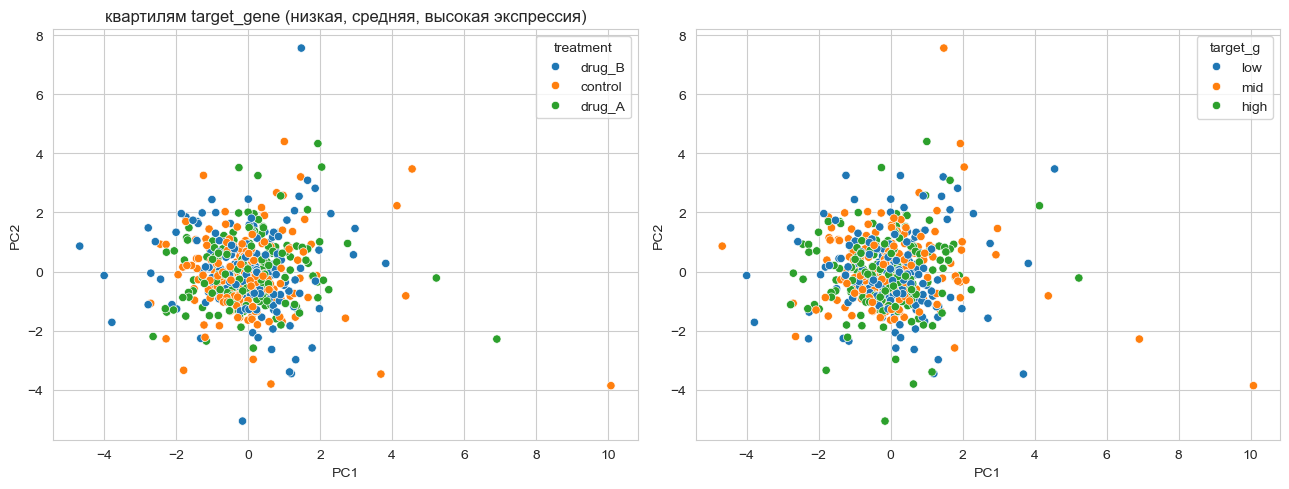

In [39]:
# 4.3 Визуализация в 2D

# TODO: Постройте scatter plot первых двух главных компонент
# TODO: Раскрасьте точки по:
#   a) treatment группам
#   b) квартилям target_gene (низкая, средняя, высокая экспрессия)

plot_df = pd.DataFrame(x_pca_2d, columns=['PC1', 'PC2'])
plot_df['treatment'] = df_genes['treatment'].values
plot_df['target_g'] = pd.qcut(df_genes['target_gene'], q=3, labels=['low', 'mid', 'high'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='treatment', ax=axes[0])
axes[0].set_title('treatment группам')

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='target_g', ax=axes[1])
axes[0].set_title('квартилям target_gene (низкая, средняя, высокая экспрессия)')

plt.tight_layout()
plt.show()

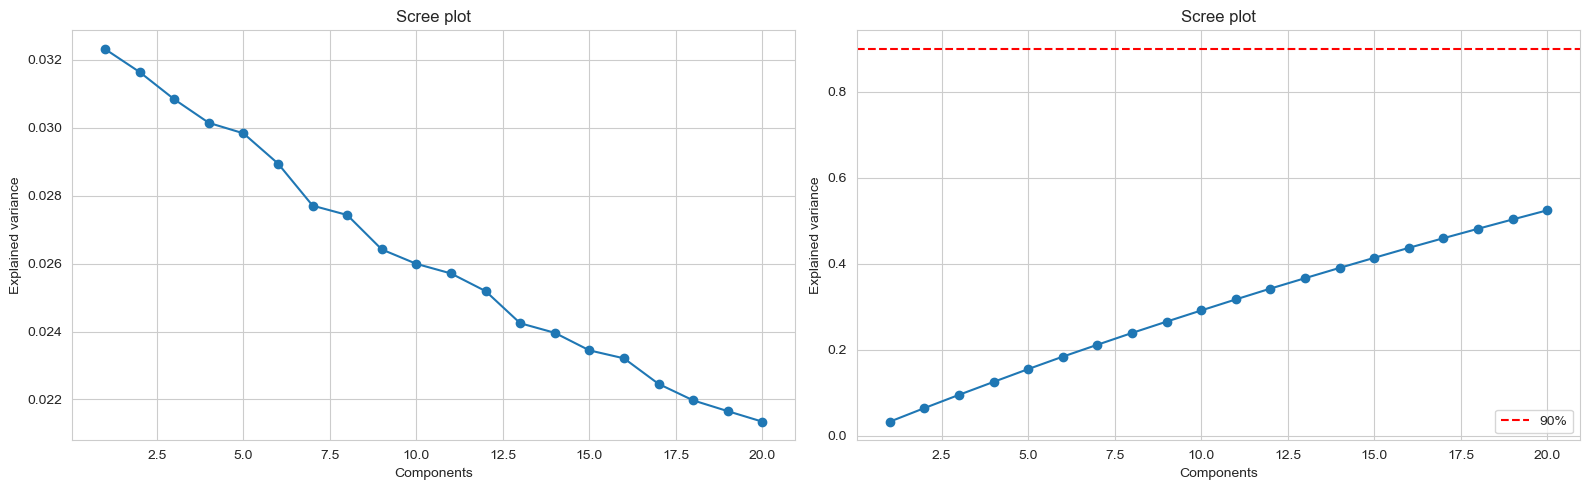

In [40]:
# 4.4 Анализ объяснённой дисперсии

# TODO: Примените PCA с n_components=20
# TODO: Постройте scree plot (explained variance vs number of components)
# TODO: Постройте cumulative explained variance
# Сколько компонент нужно, чтобы объяснить 90% дисперсии?

pca_20 = PCA(n_components=20, random_state=42)
pca_20.fit(x_genes_scaled)

explained = pca_20.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(range(1, 21), explained, marker='o')
axes[0].set_title('Scree plot')
axes[0].set_xlabel('Components') 
axes[0].set_ylabel('Explained variance')

axes[1].plot(range(1, 21), cum_explained, marker='o')
axes[1].axhline(0.9, color='r', linestyle='--', label='90%')
axes[1].set_title('Scree plot')
axes[1].set_xlabel('Components') 
axes[1].set_ylabel('Explained variance')
axes[1].legend()

plt.tight_layout()
plt.show()

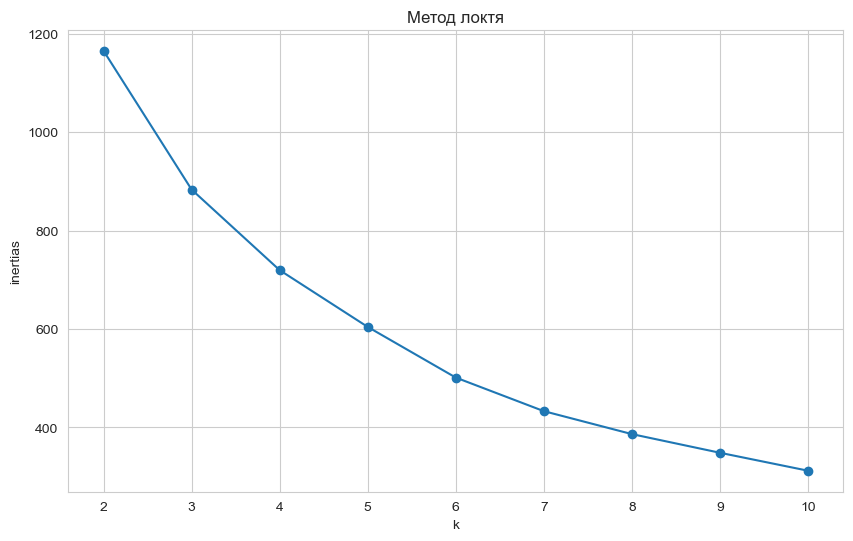

In [41]:
# 4.5 Кластеризация

from sklearn.cluster import KMeans

# TODO: Используйте метод локтя для выбора оптимального числа кластеров
# Попробуйте k от 2 до 10

inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_pca_2d)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Метод локтя')
plt.xlabel('k')
plt.ylabel('inertias')
plt.show()

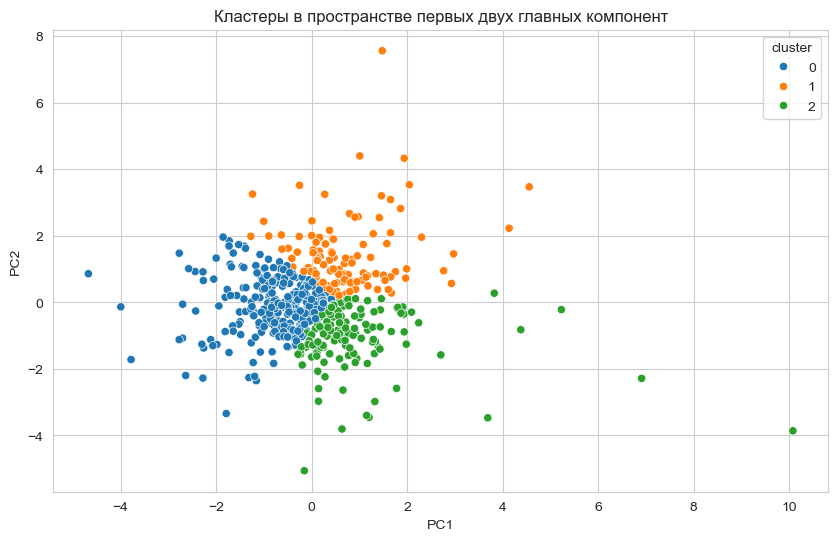

In [42]:
# TODO: Примените KMeans с оптимальным k
# TODO: Визуализируйте кластеры в пространстве первых двух главных компонент

optimal_k = 3 
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_opt.fit_predict(x_pca_2d)

plot_df['cluster'] = clusters.astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster')
plt.title('Кластеры в пространстве первых двух главных компонент')
plt.show()

In [43]:
# 4.6 Характеристика кластеров

# TODO: Для каждого кластера вычислите:
# - Средний уровень target_gene
# - Распределение по treatment группам
# - Средние значения temperature и ph

cluster_df = df_genes.copy()
cluster_df['cluster'] = clusters

cluster_summary = cluster_df.groupby('cluster').agg(
    target_gene_mean=('target_gene', 'mean'),
    temperature_mean=('temperature', 'mean'),
    ph_mean=('ph', 'mean'),
    n=('target_gene', 'size')
)

print('Сводка по кластерам')
display(cluster_summary)

print('Распределение treatment по кластерам')
display(pd.crosstab(cluster_df['cluster'], cluster_df['treatment'], normalize='index').round(3))

Сводка по кластерам


,target_gene_mean,temperature_mean,ph_mean,n
cluster,,,,
0,96.63,28.76,6.98,258
1,92.29,27.81,7.05,112
2,92.21,28.58,6.96,130


Распределение treatment по кластерам


treatment,control,drug_A,drug_B
cluster,,,
0,0.39,0.34,0.27
1,0.26,0.43,0.31
2,0.34,0.26,0.40


**Вопросы для анализа:**

1. Сколько главных компонент нужно для объяснения 90% дисперсии?
2. Можно ли визуально разделить treatment группы в пространстве главных компонент?
3. Сколько кластеров оказалось оптимальным?
4. Соответствуют ли кластеры каким-либо биологическим группам (treatment, уровни экспрессии)?
5. Какие преимущества даёт PCA для анализа данных высокой размерности?

**Ваши ответы:**
1. По расчету требуется несколько комонент для покрытия 90% дисперсии
2. Разделения ```treatment``` в 2d обычно частичное, т.е. есть перекрытие, но некоторе группы образуют более плотные области
3. Оказалось 3 оптимальных кластера
4. Можно интерпретировать через средний ```target_gene``` и ```treatment```, но это не всегда соответствует биологическим классам 
5. Метод уменьшает шум + ускоряет анализ и можно удобно визуализировать сложные данные

---

## Бонусное задание (+2 балла)

### Задача: Cross-validation и learning curves

Выберите одну из моделей из предыдущих заданий и:

1. Проведите k-fold cross-validation (k=5, k=10)
2. Постройте learning curves (train/validation scores vs training set size)
3. Постройте validation curves для одного гиперпараметра
4. Проанализируйте, есть ли у модели overfitting или underfitting
5. Предложите способы улучшения модели на основе анализа

In [44]:
# TODO: Ваш код здесь


---

## Итоговые выводы

**Напишите краткое резюме (5-7 предложений):**

1. Что вы узнали о применении машинного обучения к биологическим данным?
2. Какие модели лучше всего подходят для каких типов задач?
3. Какие трудности вы встретили?
4. Что бы вы применили в своих исследованиях?

**Ваше резюме:**
...

---

## Критерии оценки

### Задание 1 (2 балла):
- 0.5 балла: EDA с визуализацией
- 1 балл: Корректное обучение всех 5 моделей
- 0.5 балла: Анализ и ответы на вопросы

### Задание 2 (3 балла):
- 0.5 балла: Корректная обработка пропущенных значений
- 0.5 балла: Feature engineering
- 1 балл: GridSearchCV и обучение моделей
- 0.5 балла: Анализ важности признаков
- 0.5 балла: Анализ и ответы на вопросы

### Задание 3 (3 балла):
- 0.5 балла: EDA регрессионных данных
- 1 балл: Обучение всех регрессионных моделей
- 0.5 балла: Анализ residuals
- 0.5 балла: Анализ важности признаков
- 0.5 балла: Анализ и ответы на вопросы

### Задание 4 (2 балла):
- 0.5 балла: Корректное применение PCA
- 0.5 балла: Визуализация и анализ главных компонент
- 0.5 балла: Кластеризация
- 0.5 балла: Анализ и ответы на вопросы

### Бонус (+2 балла):
- 1 балл: Корректная реализация всех техник
- 1 балл: Глубокий анализ и выводы

**Максимум: 12 баллов (10 + 2 бонусных)**

---

## Полезные ресурсы

1. **Scikit-learn документация**: https://scikit-learn.org/
2. **Pandas документация**: https://pandas.pydata.org/
3. **Seaborn gallery**: https://seaborn.pydata.org/examples/index.html
4. **Machine Learning Mastery**: https://machinelearningmastery.com/